In [2]:
import pandas as pd

fname = "capacity_test_out/jmeter.csv"

df = pd.read_csv(fname)

df["power"] = 1000 * df["throughput"] / df["response_time"]

df.head(10)

,ctt,throughput,response_time,power
0,200,3.563977,72.959833,48.848475
1,400,5.178427,79.606444,65.050353
2,600,4.934194,113.711671,43.392153
3,800,13.541047,98.248130,137.824988
4,1000,16.863956,140.247819,120.243979
5,1200,20.164696,362.559034,55.617690
6,1400,22.502556,1901.102635,11.836581
7,1600,18.352862,3285.086034,5.586722


## Throughput 

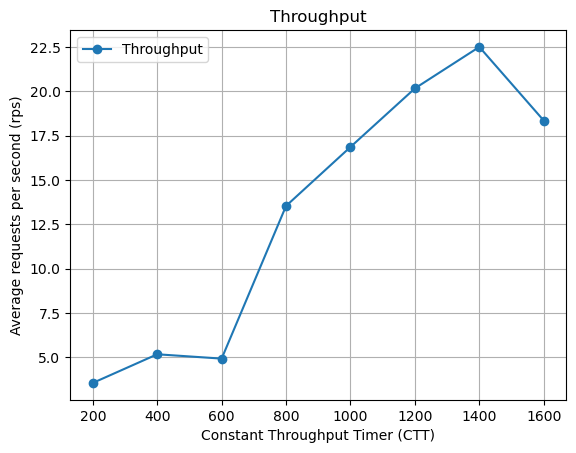

In [63]:
import matplotlib.pyplot as plt

plt.title("Throughput")
plt.xlabel("Constant Throughput Timer (CTT)")
plt.ylabel("Average requests per second (rps)")
plt.plot(df["ctt"], df["throughput"], marker="o", label="Throughput")
plt.legend()
plt.grid(True)
plt.show()

## Response time

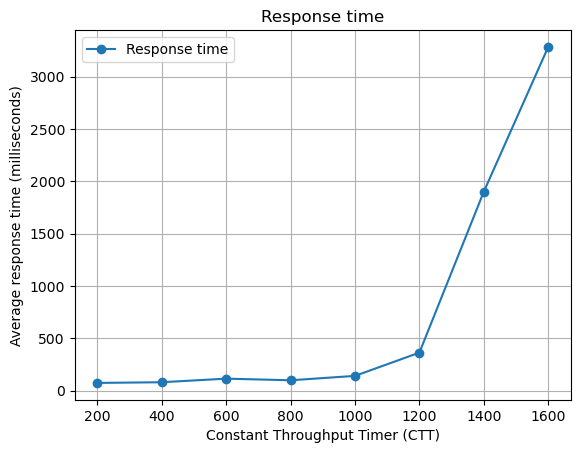

In [64]:
import matplotlib.pyplot as plt

plt.title("Response time")
plt.xlabel("Constant Throughput Timer (CTT)")
plt.ylabel("Average response time (milliseconds)")
plt.plot(df["ctt"], df["response_time"], marker="o", label="Response time")
plt.legend()
plt.grid(True)
plt.show()

## Power

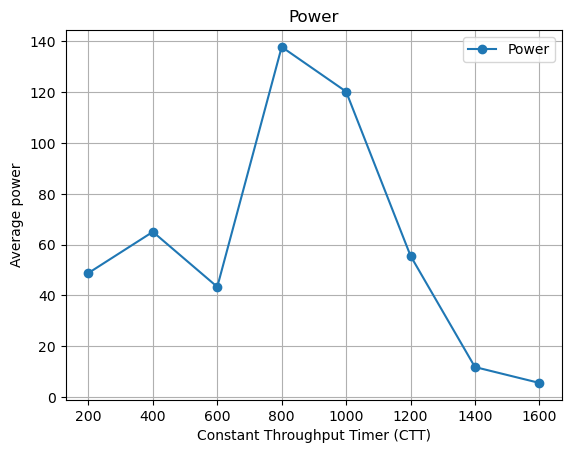

In [65]:
import matplotlib.pyplot as plt

plt.title("Power")
plt.xlabel("Constant Throughput Timer (CTT)")
plt.ylabel("Average power")
plt.plot(df["ctt"], df["power"], marker="o", label="Power")
plt.legend()
plt.grid(True)
plt.show()

## VMStat analysis

In [3]:
import pandas as pd
import numpy as np
fname = "capacity_test_out/vmstat.csv"

df = pd.read_csv(fname, dtype=float)

df.head(10)

,ctt,r,b,swpd,free,buff,cache,si,so,bi,bo,in,cs,us,sy,id,wa,st,gu
0,200.0,0.333333,0.000000,0.0,421157.311111,8671.422222,39908.511111,0.0,0.0,11.555556,3.711111,998.311111,166.733333,0.000000,13.111111,86.822222,0.000000,0.0,0.0
1,400.0,0.561111,0.000000,0.0,423626.222222,6396.200000,39996.977778,0.0,0.0,55.022222,4.711111,1191.988889,263.622222,0.011111,25.494444,74.294444,0.022222,0.0,0.0
2,600.0,1.033333,0.000000,0.0,420062.555556,9334.066667,40229.866667,0.0,0.0,44.561111,4.911111,1193.883333,345.150000,0.011111,42.005556,57.788889,0.022222,0.0,0.0
3,800.0,1.322222,0.011111,0.0,422324.311111,6404.377778,40379.422222,0.0,0.0,57.227778,5.350000,1639.788889,419.144444,0.011111,45.933333,53.788889,0.022222,0.0,0.0
4,1000.0,1.638889,0.000000,0.0,421242.222222,6418.733333,40549.666667,0.0,0.0,55.133333,6.111111,1739.194444,478.822222,0.011111,53.588889,46.111111,0.016667,0.0,0.0
5,1200.0,1.500000,0.005556,0.0,418862.155556,6500.777778,40752.733333,0.0,0.0,6.122222,6.216667,1550.550000,551.411111,0.000000,57.883333,41.838889,0.000000,0.0,0.0
6,1400.0,3.188889,0.005556,0.0,412802.222222,6417.577778,40896.822222,0.0,0.0,57.100000,6.900000,1543.700000,806.527778,0.011111,64.683333,34.972222,0.016667,0.0,0.0
7,1600.0,4.472222,0.005556,0.0,410907.200000,6420.911111,40649.355556,0.0,0.0,57.188889,6.511111,1352.272222,788.333333,0.016667,62.044444,37.511111,0.027778,0.0,0.0


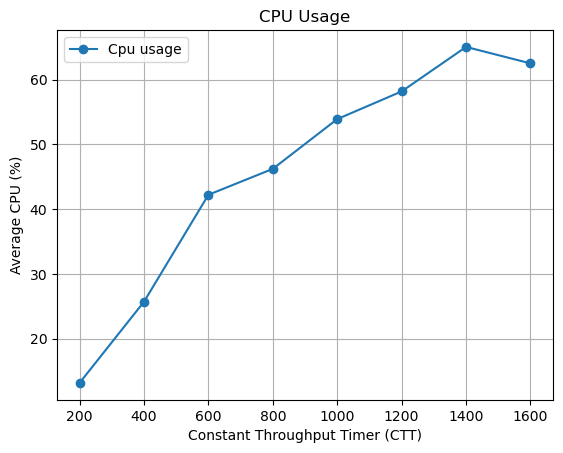

In [28]:
import matplotlib.pyplot as plt

plt.title("CPU Usage")
plt.xlabel("Constant Throughput Timer (CTT)")
plt.ylabel("Average CPU (%)")
df["usage"] = 1 - df["id"] / 100
plt.plot(df["ctt"], df["usage"] * 100, marker="o", label="Cpu usage")
plt.legend()
plt.grid(True)
plt.show() 

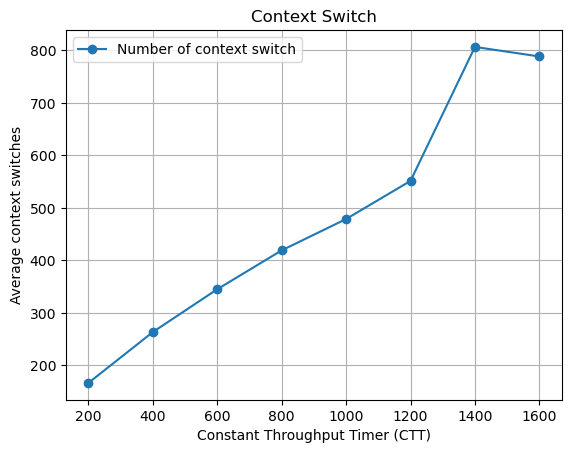

In [71]:
import matplotlib.pyplot as plt

plt.title("Context Switch")
plt.xlabel("Constant Throughput Timer (CTT)")
plt.ylabel("Average context switches")
plt.plot(df["ctt"], df["cs"], marker="o", label="Number of context switch")
plt.legend()
plt.grid(True)
plt.show() 

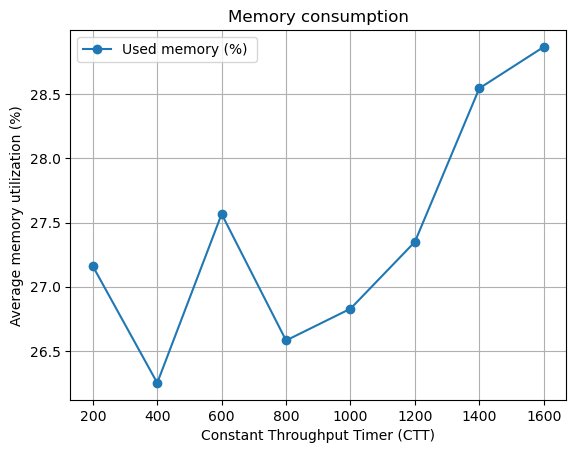

,ctt,r,b,swpd,free,buff,cache,si,so,bi,...,in,cs,us,sy,id,wa,st,gu,used,used_perc
0,200.0,0.333333,0.000000,0.0,421157.311111,8671.422222,39908.511111,0.0,0.0,11.555556,...,998.311111,166.733333,0.000000,13.111111,86.822222,0.000000,0.0,0.0,1.389226e+08,27.159848
1,400.0,0.561111,0.000000,0.0,423626.222222,6396.200000,39996.977778,0.0,0.0,55.022222,...,1191.988889,263.622222,0.011111,25.494444,74.294444,0.022222,0.0,0.0,1.342670e+08,26.249649
2,600.0,1.033333,0.000000,0.0,420062.555556,9334.066667,40229.866667,0.0,0.0,44.561111,...,1193.883333,345.150000,0.011111,42.005556,57.788889,0.022222,0.0,0.0,1.410014e+08,27.566252
3,800.0,1.322222,0.011111,0.0,422324.311111,6404.377778,40379.422222,0.0,0.0,57.227778,...,1639.788889,419.144444,0.011111,45.933333,53.788889,0.022222,0.0,0.0,1.359595e+08,26.580545
4,1000.0,1.638889,0.000000,0.0,421242.222222,6418.733333,40549.666667,0.0,0.0,55.133333,...,1739.194444,478.822222,0.011111,53.588889,46.111111,0.016667,0.0,0.0,1.372262e+08,26.828187


In [25]:
import matplotlib.pyplot as plt

plt.title("Memory consumption")
plt.xlabel("Constant Throughput Timer (CTT)")
plt.ylabel("Average memory utilization (%)")
df["used"] = 5.115e8 - (df["free"]*1000)
df["used"] += (df["buff"] + df["cache"]) * 1000

df["used_perc"] = df["used"]/(5.115e8) * 100

plt.plot(df["ctt"], df["used_perc"], marker="o", label="Used memory (%) ")

plt.legend()
plt.grid(True)
plt.ticklabel_format(useOffset=False)
plt.show() 
df.head()

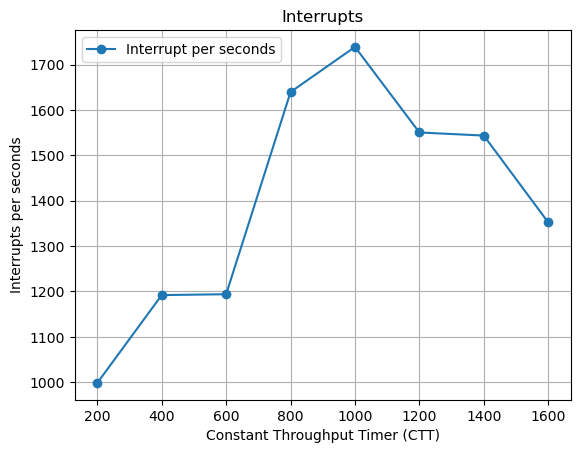

In [73]:
import matplotlib.pyplot as plt

plt.title("Interrupts")
plt.xlabel("Constant Throughput Timer (CTT)")
plt.ylabel("Interrupts per seconds")
plt.plot(df["ctt"], df["in"], marker="o", label="Interrupt per seconds")
plt.legend()
plt.grid(True)
plt.show() 

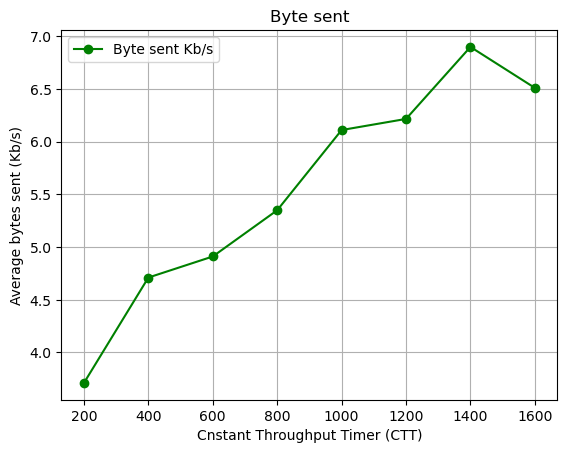

In [46]:
import matplotlib.pyplot as plt

plt.title("Byte sent")
plt.xlabel("Cnstant Throughput Timer (CTT)")
plt.ylabel("Average bytes sent (Kb/s)")
plt.plot(df["ctt"], df["bo"], marker="o", label="Byte sent Kb/s", color="g")
plt.legend()
plt.grid(True)
plt.show()

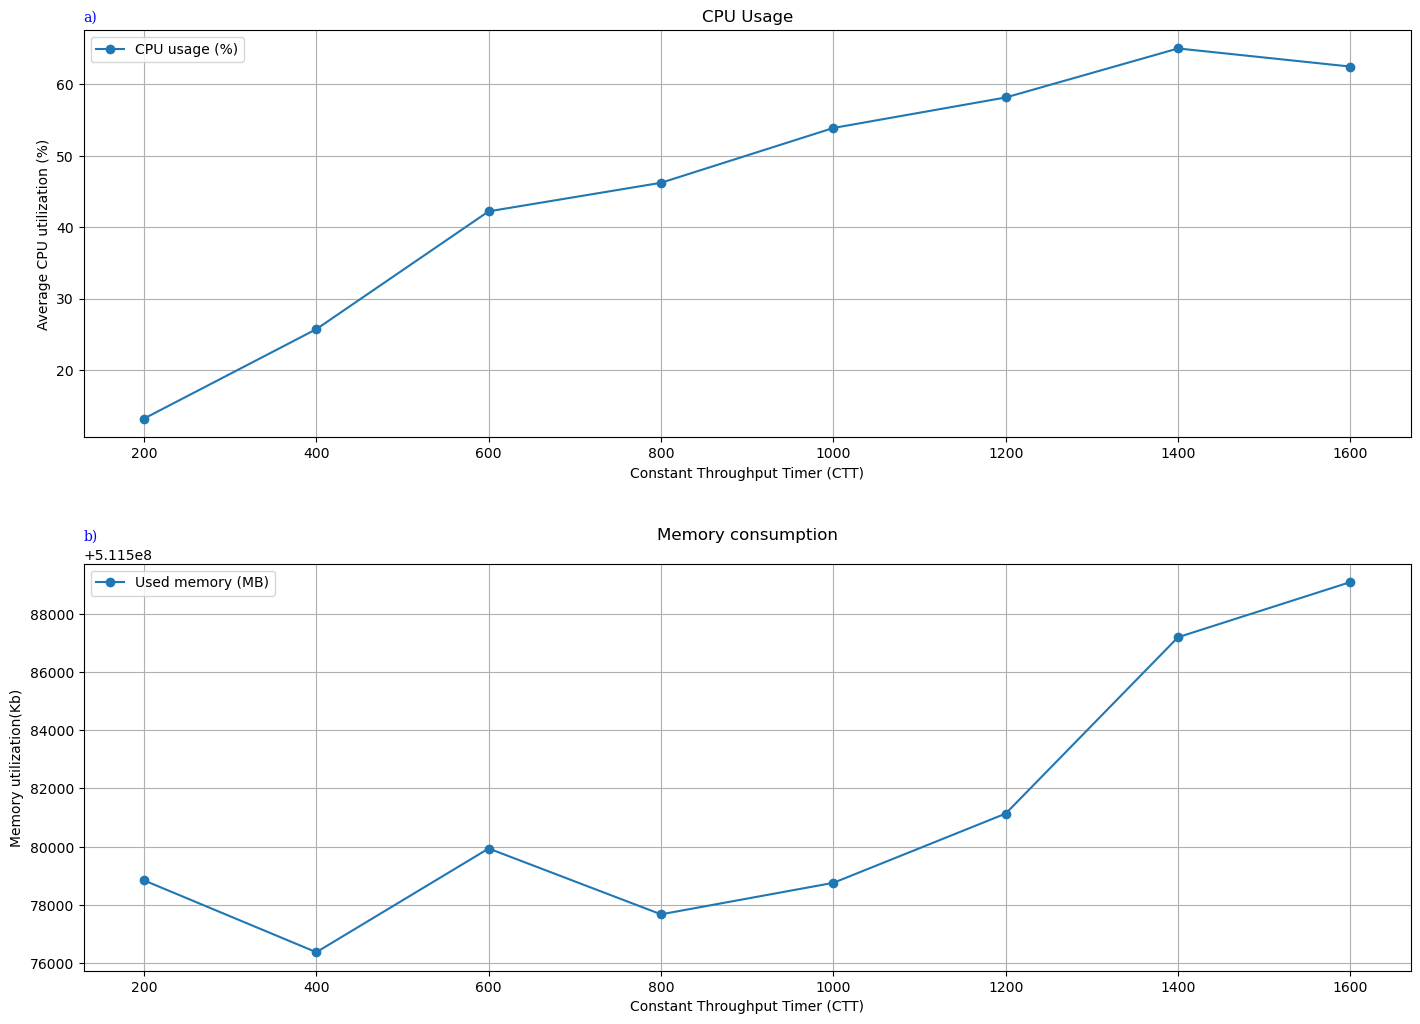

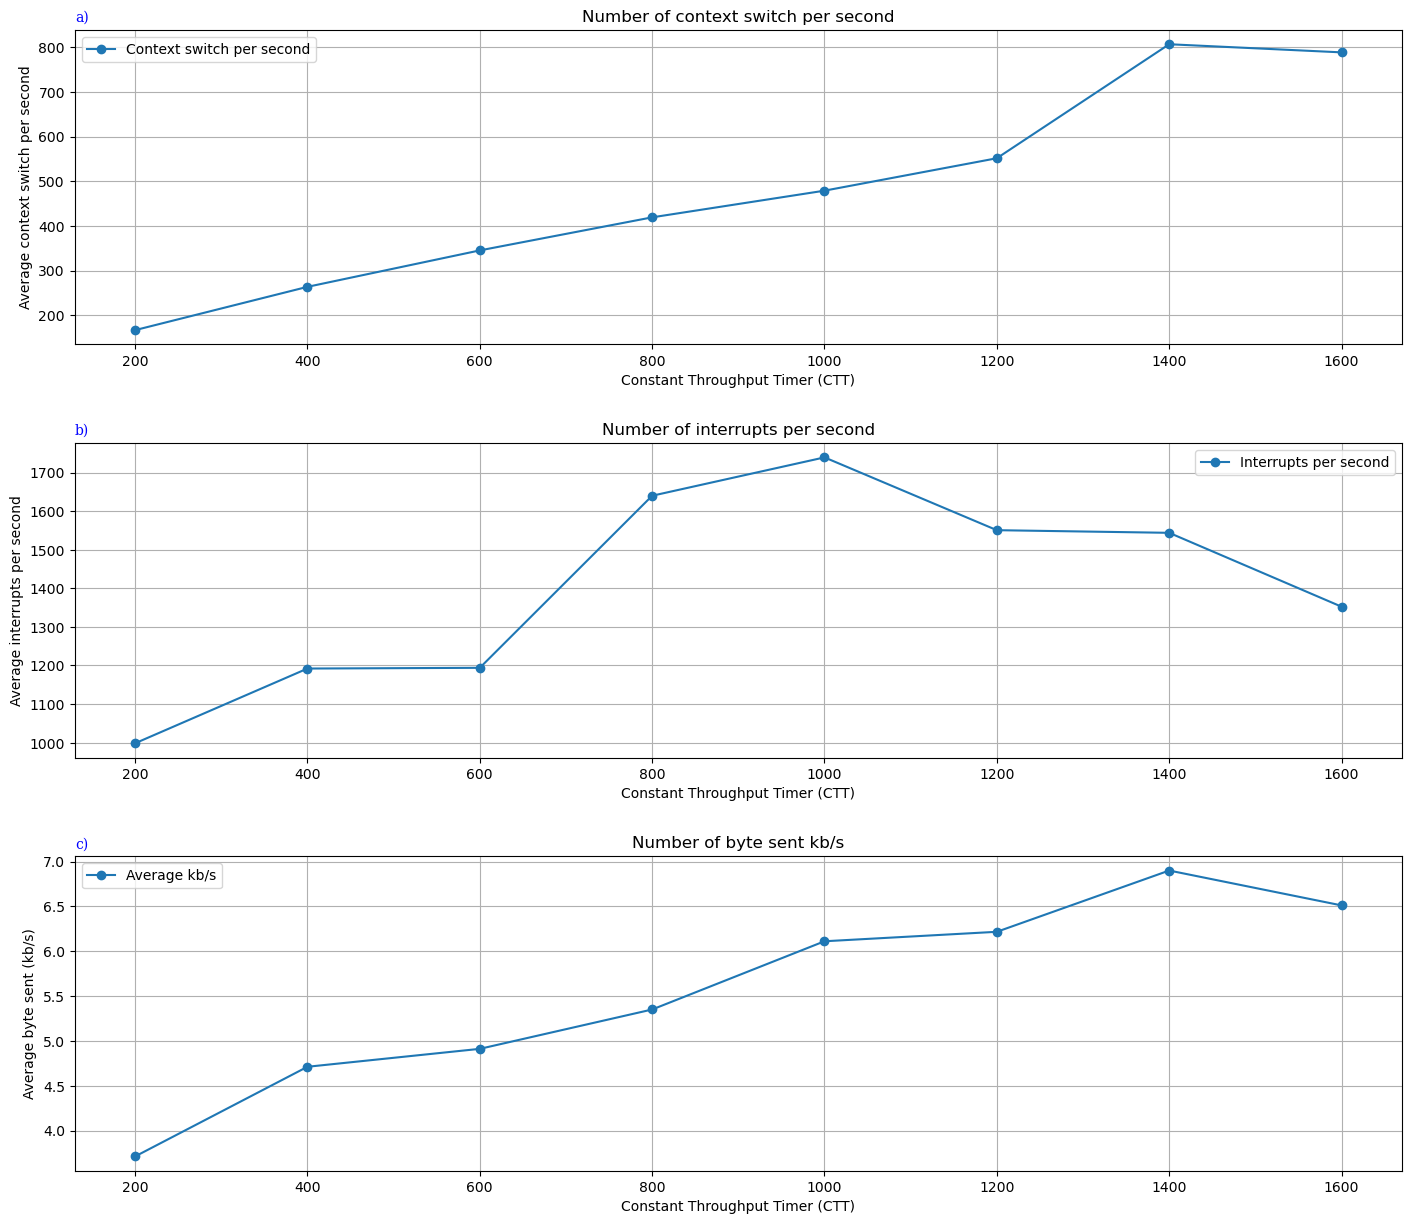

In [65]:
import matplotlib.pyplot as plt

def plot(ax: plt.Axes, title: str, label: str, xlabel: str, ylabel: str, x, y, legend: str, color: str = "b") -> None:
    ax.set_title(title)
    ax.set_title(label, fontfamily='serif', loc='left', fontsize='medium', color="b")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.plot(x, y, marker="o", label=legend)
    ax.legend()
    ax.grid(True)
    return

fig, axs = plt.subplots(2, figsize=(14, 10))

fig.tight_layout(h_pad=7, w_pad=5)

subplots_info = [
    {
        "ax": axs[0],
        "label": "a)",
        "title": "CPU Usage",
        "xlabel": "Constant Throughput Timer (CTT)",
        "ylabel": "Average CPU utilization (%)",
        "x": df["ctt"],
        "y": (1 - df["id"] / 100) * 100,
        "legend": "CPU usage (%)"
    },
    {
        "ax": axs[1],
        "title": "Memory consumption",
        "label": "b)",
        "xlabel": "Constant Throughput Timer (CTT)",
        "ylabel": "Memory utilization(Kb)",
        "x": df["ctt"],
        "y": 512000000 - df["free"],
        "legend": "Used memory (MB)",
    },
]

for info in subplots_info:
    plot(info["ax"], info["title"], info["label"], info["xlabel"], info["ylabel"], info["x"],  info["y"], info["legend"])

fig, axs = plt.subplots(3, figsize=(14, 12))

fig.tight_layout(h_pad=5, w_pad=5)

subplots_info = [
    {
        "ax": axs[0],
        "label": "a)",
        "title": "Number of context switch per second",
        "xlabel": "Constant Throughput Timer (CTT)",
        "ylabel": "Average context switch per second",
        "x": df["ctt"],
        "y": df["cs"],
        "legend": "Context switch per second",
    },
    {
        "ax": axs[1],
        "label": "b)",
        "title": "Number of interrupts per second",
        "xlabel": "Constant Throughput Timer (CTT)",
        "ylabel": "Average interrupts per second",
        "x": df["ctt"],
        "y": df["in"],
        "legend": "Interrupts per second",
    },
    {
        "ax": axs[2],
        "label": "c)",
        "title": "Number of byte sent kb/s",
        "xlabel": "Constant Throughput Timer (CTT)",
        "ylabel": "Average byte sent (kb/s)",
        "x": df["ctt"],
        "y": df["bo"],
        "legend": "Average kb/s",
    }
]
for info in subplots_info:
    plot(info["ax"], info["title"], info["label"], info["xlabel"], info["ylabel"], info["x"],  info["y"], info["legend"])


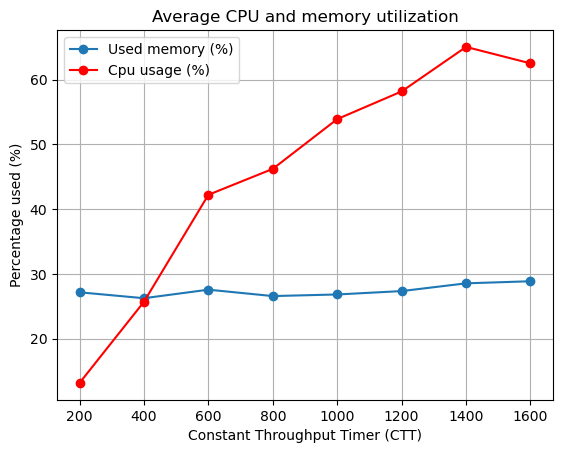

,ctt,r,b,swpd,free,buff,cache,si,so,bi,...,cs,us,sy,id,wa,st,gu,used,used_perc,usage
0,200.0,0.333333,0.000000,0.0,421157.311111,8671.422222,39908.511111,0.0,0.0,11.555556,...,166.733333,0.000000,13.111111,86.822222,0.000000,0.0,0.0,1.389226e+08,27.159848,0.131778
1,400.0,0.561111,0.000000,0.0,423626.222222,6396.200000,39996.977778,0.0,0.0,55.022222,...,263.622222,0.011111,25.494444,74.294444,0.022222,0.0,0.0,1.342670e+08,26.249649,0.257056
2,600.0,1.033333,0.000000,0.0,420062.555556,9334.066667,40229.866667,0.0,0.0,44.561111,...,345.150000,0.011111,42.005556,57.788889,0.022222,0.0,0.0,1.410014e+08,27.566252,0.422111
3,800.0,1.322222,0.011111,0.0,422324.311111,6404.377778,40379.422222,0.0,0.0,57.227778,...,419.144444,0.011111,45.933333,53.788889,0.022222,0.0,0.0,1.359595e+08,26.580545,0.462111
4,1000.0,1.638889,0.000000,0.0,421242.222222,6418.733333,40549.666667,0.0,0.0,55.133333,...,478.822222,0.011111,53.588889,46.111111,0.016667,0.0,0.0,1.372262e+08,26.828187,0.538889


In [33]:
import matplotlib.pyplot as plt

plt.title("Average CPU and memory utilization")

plt.xlabel("Constant Throughput Timer (CTT)")
plt.ylabel("Percentage used (%)")

plt.plot(df["ctt"], df["used_perc"], marker="o", label="Used memory (%)")
plt.plot(df["ctt"], df["usage"] * 100, marker="o", label="Cpu usage (%)", color="r")

plt.legend()
plt.grid(True)
plt.ticklabel_format(useOffset=False)
plt.show() 
df.head()